# Table of Contents

- [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-EDA)
- [Dataset Overview](#Dataset-Overview)
- [Missing Values](#Missing-Values)
- [Job Role Distribution](#Job-Role-Distribution)
- [Job Locations](#Job-Locations)
- [Salary Transparency](#Salary-Transparency)

- [Research Question Analysis](#Research-Question-Analysis)

  - [Skills Demand](#Skills-Demand)
    - [Average Skill Count by Role](#Average-Skill-Count-by-Role)
    - [Top 15 Most Frequently Requested Skills](#Top-15-Most-Frequently-Requested-Skills)

  - [Regional Differences](#Regional-Differences)
    - [Skill Requirements by Canton](#Skill-Requirements-by-Canton)
    - [Salary Transparency by Canton](#Salary-Transparency-by-Canton)

  - [Industry Differences](#Industry-Differences)
    - [Skill Requirements by Industry](#Skill-Requirements-by-Industry)

  - [Seniority Differences](#Seniority-Differences)
    - [Skill Requirements by Seniority](#Skill-Requirements-by-Seniority)

  - [Macro Labor Market Context](#Macro-Labor-Market-Context)

  - [Salary Transparency Patterns](#Salary-Transparency-Patterns)

- [Summary of Findings](#Summary-of-Findings)

- [Data Limitations](#Data-Limitations)


# Exploratory Data Analysis (EDA)

This section explores the merged dataset containing Swiss job postings and macro-level vacancy statistics from the Swiss Federal Statistical Office (BFS). The objective is to understand the dataset structure, identify potential data quality issues, and explore key variables before addressing the research questions.

## Import Libraries

In this step, the necessary Python libraries for data analysis and visualization are imported. Pandas is used for data manipulation, NumPy for numerical operations, and Matplotlib and Seaborn for visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load the Dataset

The dataset used in this analysis contains the merged job postings data (micro-level data) and macro labor market statistics obtained from BFS (macro-level data). The dataset is loaded from the processed data folder of the project repository.

In [3]:
df = pd.read_csv("../data/processed/jobs_merged_final.csv")

df.head()

,job_id,title,company,role,seniority,city,canton,region,posted_date,quarter,...,workload_max,salary_available,salary_min,salary_max,skills,skill_count,industry,macro_vacancies_region,macro_vacancies_industry,description
0,43725c60f2a0e7a20223831427ec1c5733c8e34c,Mission étudiante 40% : Data Analyst,Academic Work Switzerland,data scientist,NaN,Montreux,VD,Lake Geneva Region,2026-02-20,2026Q1,...,50.0,0,NaN,NaN,"['excel', 'power bi']",2,49-53 Transport and storage,13400.0,3746.0,About the job Tu es actuellement étudiant.e ? ...
1,929b4733c6e1c66d045413a3373023e435e25a0c,Junior Survey Data Analyst 20%,Academic Work Switzerland,data scientist,junior,Lausanne,VD,Lake Geneva Region,2026-02-10,2026Q1,...,20.0,0,NaN,NaN,['excel'],1,62-63 IT services,13400.0,3825.0,About the job Tu es étudiant.e et recherches u...
2,da46ba822882645bc160031dd473b01555e8e9c8,Merchandising & Data Analyst (H/F),Vilebrequin,data scientist,NaN,Plan-les-Ouates,GE,Lake Geneva Region,2026-02-06,2026Q1,...,100.0,0,NaN,NaN,['excel'],1,10-33 Manufacturing,13400.0,10980.0,"About the job Née en 1971 à St-Tropez, la mais..."
3,face52ba0e66311274a47f6df9fbf699abc6bc3d,Spécialiste informatique - Interfaces et donné...,Transports publics fribourgeois (TPF) SA,data scientist,NaN,Givisiez,FR,Espace Mittelland,2026-03-01,2026Q1,...,100.0,0,NaN,NaN,"['pandas', 'python', 'sql']",3,49-53 Transport and storage,14724.0,3746.0,About the job La mobilité est la raison d'être...
4,0e5906d2b6906c6f4eac077cdb6cda27d9955253,Data Scientist - Innovation Collaborations,EPFL,data scientist,NaN,Lausanne,VD,Lake Geneva Region,2026-02-20,2026Q1,...,100.0,0,NaN,NaN,"['artificial intelligence', 'machine learning']",2,85 Education,13400.0,2122.0,"About the job EPFL, the Swiss Federal Institut..."


## Dataset Overview

This section provides a general overview of the dataset. It includes information about the number of observations, the number of variables, and the data types of each column. Understanding the structure of the dataset is an important first step before performing further analysis.

In [4]:
print("Dataset shape:", df.shape)

df.shape
df.columns
df.info()

Dataset shape: (743, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 743 entries, 0 to 742
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   job_id                    743 non-null    object 
 1   title                     743 non-null    object 
 2   company                   743 non-null    object 
 3   role                      743 non-null    object 
 4   seniority                 349 non-null    object 
 5   city                      657 non-null    object 
 6   canton                    644 non-null    object 
 7   region                    644 non-null    object 
 8   posted_date               740 non-null    object 
 9   quarter                   743 non-null    object 
 10  macro_quarter             743 non-null    object 
 11  workload_min              723 non-null    float64
 12  workload_max              723 non-null    float64
 13  salary_available          743 non-null  

In [5]:
df.describe()

,workload_min,workload_max,salary_available,salary_min,salary_max,skill_count,macro_vacancies_region,macro_vacancies_industry
count,723.000000,723.000000,743.000000,9.000000,9.000000,743.000000,641.000000,740.000000
mean,93.326418,99.343015,0.012113,95777.777778,109666.666667,2.823688,16493.887676,6445.483784
std,12.820677,5.956087,0.109464,25183.217516,33387.872050,4.255313,4644.198276,4165.428528
min,5.000000,15.000000,0.000000,36000.000000,36000.000000,0.000000,1714.000000,2122.000000
25%,80.000000,100.000000,0.000000,88000.000000,88000.000000,0.000000,13400.000000,3825.000000
50%,100.000000,100.000000,0.000000,110000.000000,130000.000000,1.000000,14724.000000,3825.000000
75%,100.000000,100.000000,0.000000,110000.000000,130000.000000,4.000000,22114.000000,10980.000000
max,100.000000,100.000000,1.000000,115000.000000,135000.000000,46.000000,23842.000000,14561.000000


The descriptive statistics provide a summary of the numerical variables in the dataset, including skill counts and vacancy indicators. These statistics help identify the general distribution of job requirements and macro labor market indicators.

## Missing Values

In this step, missing values are examined across all variables. Identifying missing data is important to understand potential limitations of the dataset and determine whether additional cleaning or adjustments may be required during analysis.

In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values

salary_min                  734
salary_max                  734
seniority                   394
macro_vacancies_region      102
canton                       99
region                       99
city                         86
workload_min                 20
workload_max                 20
macro_vacancies_industry      3
posted_date                   3
industry                      0
skill_count                   0
skills                        0
job_id                        0
salary_available              0
title                         0
macro_quarter                 0
quarter                       0
role                          0
company                       0
description                   0
dtype: int64

The missing-value analysis shows that `salary_min`, `salary_max`, and `seniority` contain the largest number of missing values. This is expected because salary details are rarely disclosed in Swiss job advertisements, and seniority is not always explicitly stated in job titles. In addition, some rows still lack complete regional information, which may slightly affect regional comparisons.

## Job Role Distribution


In [7]:
role_counts = df["role"].value_counts()

role_counts

role
data engineer                448
data scientist               122
data analyst                  95
machine learning engineer     42
ai engineer                   36
Name: count, dtype: int64

The role distribution shows that Data Engineer positions appear most frequently in the dataset, followed by Data Scientist and Data Analyst roles. This suggests a strong demand for data engineering skills in the Swiss data job market. More specialized roles such as AI Engineer and Machine Learning Engineer appear less often, indicating that these positions are more niche and less widely advertised.

## Job Locations


In [8]:
location_counts = df["canton"].value_counts()

df["canton"].value_counts().head(10)


canton
ZH    242
GE     87
VD     76
BE     59
AG     30
SG     26
VS     21
BS     21
LU     12
NE     11
Name: count, dtype: int64

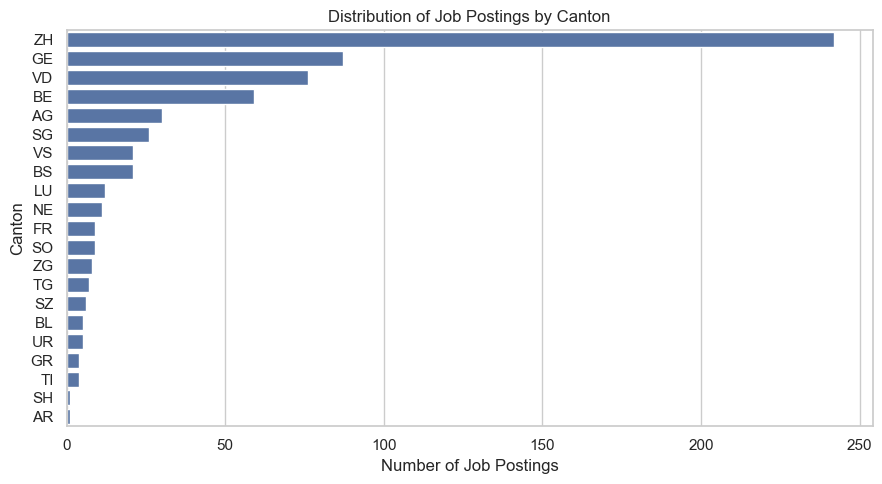

In [9]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index
)

plt.title("Distribution of Job Postings by Canton")
plt.xlabel("Number of Job Postings")
plt.ylabel("Canton")

plt.tight_layout()
plt.show()

*Figure: Distribution of job postings by canton in the dataset.*

The geographic distribution shows that job postings are concentrated in a few key Swiss cantons. Zurich (ZH), Vaud (VD), and Bern (BE) appear frequently, reflecting major economic and technological hubs in Switzerland.

Although the canton mapping has been improved during preprocessing, some postings still lack precise regional information. Therefore, a small number of entries remain without a mapped region.

## Salary Transparency

The results show that salary information is available only in a portion of job postings, indicating limited salary transparency in the Swiss job market. This supports the relevance of salary disclosure as a key analytical dimension in this project.

In [10]:
salary_rate = df["salary_available"].mean()

print("Salary transparency rate:", round(salary_rate*100,2), "%")

Salary transparency rate: 1.21 %


Salary information is provided in only about **1.2% of job postings**, indicating extremely low salary transparency in the Swiss data job market. Most employers appear to omit salary details in job advertisements and may disclose compensation later during the recruitment process.

## Initial Observations

The exploratory analysis shows that the dataset contains 743 job postings related to data-oriented roles, including positions such as Data Analyst, Data Scientist, and Data Engineer.

The postings are concentrated in selected cantons and industries, reflecting the structure of the Swiss data job market. In addition, salary information is only available for a subset of advertisements, indicating limited salary transparency.

Overall, the EDA provides a solid foundation for the next stage of the project, where the research questions will be examined in more detail.

___


# Research Question Analysis

After completing the exploratory data analysis, the following sections examine the research questions defined in the feasibility study. These analyses focus on skill demand, regional differences in job postings, and salary transparency patterns in the Swiss data job market.

## Skills Demand

The first research question investigates which skills are most commonly required in Swiss data-related job postings. By analyzing the number of skills mentioned in job advertisements, we can gain insight into the complexity and diversity of skill requirements in the data job market.

### Average Skill Count by Role

The number of skills mentioned in job postings can provide insight into the complexity and breadth of job requirements for different roles. By comparing the average number of listed skills across roles, it is possible to understand which positions tend to require broader technical competencies.

In [11]:
avg_skill_by_role = (
    df.groupby("role")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

avg_skill_by_role

role
machine learning engineer    7.238095
data scientist               4.565574
ai engineer                  4.138889
data analyst                 2.389474
data engineer                1.921875
Name: skill_count, dtype: float64

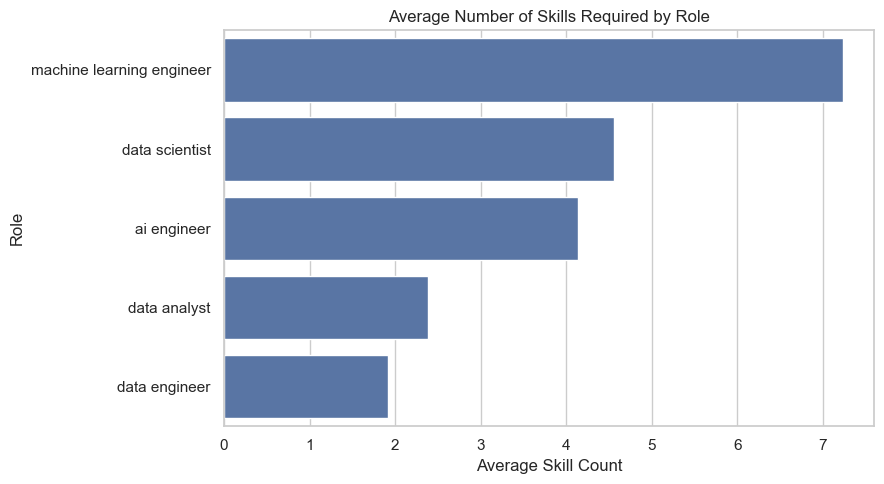

In [12]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=avg_skill_by_role.values,
    y=avg_skill_by_role.index
)

plt.title("Average Number of Skills Required by Role")
plt.xlabel("Average Skill Count")
plt.ylabel("Role")

plt.tight_layout()
plt.show()

*Figure: Average number of skills required by role.*

The results show that some roles require a larger number of skills than others. Positions such as Machine Learning Engineer and Data Scientist tend to involve more diverse skill requirements, reflecting the technical complexity of these roles. In contrast, Data Analyst and Data Engineer positions list fewer explicit skills in job advertisements, which may reflect differences in how job requirements are described across roles.

### Top 15 Most Frequently Requested Skills

To better understand which technologies are most demanded in the Swiss data job market, the skills extracted from job postings are analyzed. The following chart shows the most frequently mentioned skills across all job advertisements in the dataset.

In [13]:
import ast
from collections import Counter

def parse_skills(x):
    try:
        return [s.strip().lower() for s in ast.literal_eval(x)]
    except:
        return []

df["skills_list"] = df["skills"].apply(parse_skills)

all_skills = []

for skills in df["skills_list"]:
    all_skills.extend(skills)

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.most_common(15),
    columns=["skill","count"]
)

top_skills

,skill,count
0,python,165
1,sql,99
2,azure,96
3,ci/cd,88
4,machine learning,86
5,r,69
6,kubernetes,55
7,aws,54
8,data analysis,50
9,docker,49


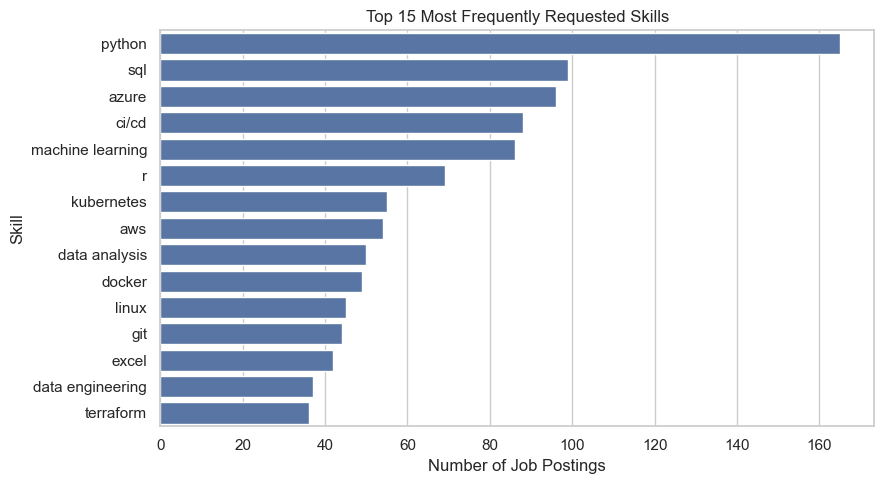

In [14]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=top_skills,
    x="count",
    y="skill"
)

plt.title("Top 15 Most Frequently Requested Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

*Figure: Top 15 most frequently requested skills in Swiss data-related job postings.*

The chart highlights the most frequently requested skills in Swiss data-related job postings. These technologies represent the core technical competencies expected from candidates in the data job market.

The presence of programming languages, data analysis tools, and machine learning frameworks indicates that modern data roles require a combination of programming, statistical analysis, and data processing capabilities.

## Industry Differences

This section examines whether job requirements differ across locations in Switzerland. To explore regional differences, the analysis first compares the average number of skills mentioned in job postings across cantons. The number of required skills can provide an indication of the complexity and breadth of job requirements in different regions.

In addition, salary transparency across cantons is analyzed by comparing the proportion of job advertisements that include salary information. This helps identify whether some regions are more transparent about compensation than others.

### Skill Requirements by Canton
To explore regional differences in job requirements, the analysis examines the average number of skills mentioned in job postings across Swiss cantons. 

The number of required skills can provide an indication of the complexity and diversity of technical requirements in different regions. By comparing the average skill count across cantons, we can identify whether certain regions tend to demand broader technical competencies in data-related roles.

In [15]:
skills_region = (
    df[df["canton"].notna()]
    .groupby("canton")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

skills_region

canton
ZG    4.625000
SZ    3.833333
ZH    3.785124
GE    3.701149
AG    2.866667
BS    2.666667
VD    2.447368
BL    2.400000
GR    2.250000
BE    2.050847
LU    1.750000
NE    1.636364
SO    1.555556
TI    1.500000
VS    1.238095
SG    0.923077
TG    0.428571
UR    0.400000
FR    0.333333
AR    0.000000
SH    0.000000
Name: skill_count, dtype: float64

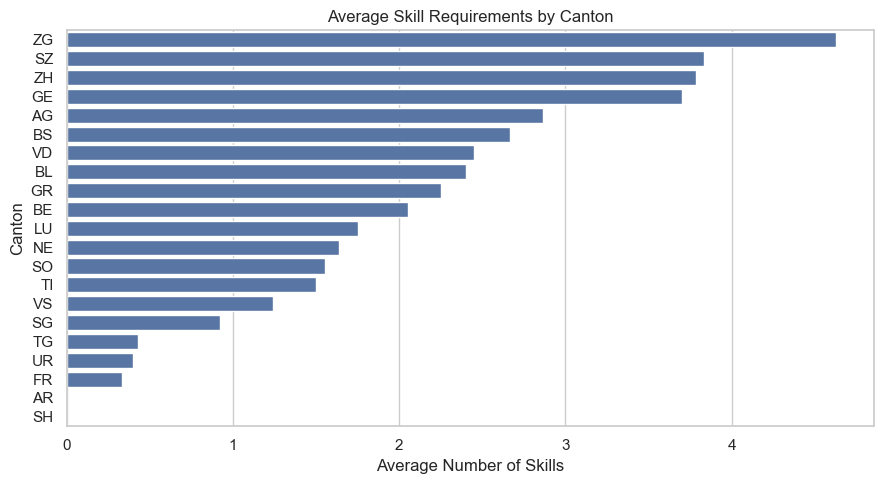

In [16]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=skills_region.values,
    y=skills_region.index
)

plt.title("Average Skill Requirements by Canton")
plt.xlabel("Average Number of Skills")
plt.ylabel("Canton")

plt.tight_layout()
plt.show()

*Figure: Average number of required skills in job postings across Swiss cantons.*

The results show that the average number of required skills varies across Swiss cantons. Regions with strong technology hubs may show higher average skill requirements because employers in these areas often look for candidates with broader technical competencies.

However, these differences should be interpreted with caution because the number of job postings varies across cantons, and some regions contain relatively few observations.

### Skill Requirements by Industry
To further examine differences in job requirements, the analysis compares the average number of skills mentioned in job postings across industries. This helps identify whether certain industries require broader technical competencies in data-related roles.



In [22]:
skills_industry = (
    df.groupby("industry")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

skills_industry


industry
68-75 Real estate & professional services    5.769231
64-66 Finance and Insurance                  4.073684
58-63 ICT                                    3.625000
49-53 Transport and storage                  2.944444
62-63 IT services                            2.711382
85 Education                                 2.493506
10-33 Manufacturing                          2.145833
86-88 Health and social work                 1.986111
41-43 Construction                           1.200000
84 Public administration                     1.032258
Name: skill_count, dtype: float64

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


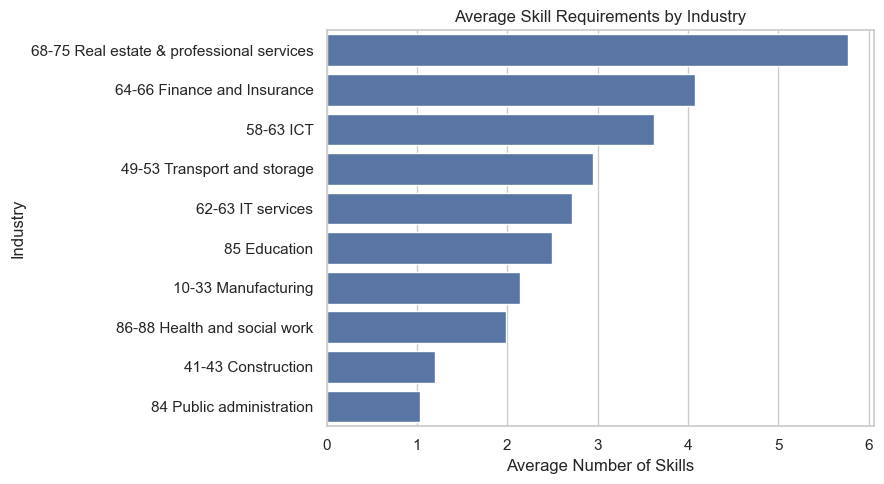

In [23]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=skills_industry.values,
    y=skills_industry.index
)

plt.title("Average Skill Requirements by Industry")
plt.xlabel("Average Number of Skills")
plt.ylabel("Industry")

plt.tight_layout()
plt.show()


*Figure: Average number of required skills across industries.*


The results show that the average number of required skills varies across industries. 
Industries such as Real Estate & Professional Services and Finance & Insurance show the highest average number of required skills, suggesting that employers in these sectors may expect candidates to possess broader technical competencies.

Technology-related sectors such as ICT and IT services also show relatively high skill requirements, reflecting the technical nature of data-related roles in these industries.

In contrast, industries such as Public Administration and Construction show lower average skill counts. However, these results should be interpreted with caution because the number of job postings varies across industries and some sectors contain relatively few observations.


## Seniority Differences

### Skill Requirements by Seniority
Seniority levels may influence the complexity of job requirements. By comparing the average number of required skills across seniority levels, the analysis explores whether more senior roles require broader technical competencies.


In [19]:
skills_seniority = (
    df[df["seniority"].notna()]
    .groupby("seniority")["skill_count"]
    .mean()
    .sort_values(ascending=False)
)

skills_seniority


seniority
mid       4.013889
senior    3.446281
intern    3.318182
lead      3.048780
junior    2.966667
Name: skill_count, dtype: float64

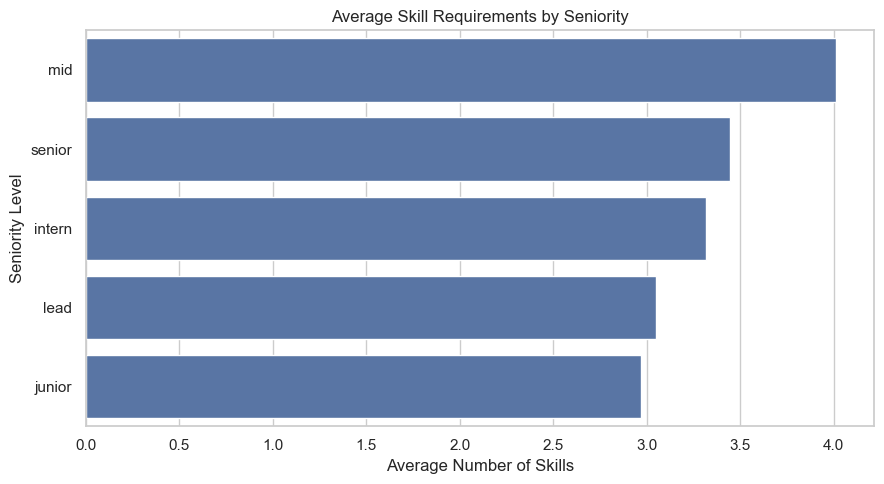

In [20]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=skills_seniority.values,
    y=skills_seniority.index
)

plt.title("Average Skill Requirements by Seniority")
plt.xlabel("Average Number of Skills")
plt.ylabel("Seniority Level")

plt.tight_layout()
plt.show()


*Figure: Average number of required skills by seniority level.*


The results suggest that job requirements vary across seniority levels. Senior positions generally show higher average skill counts, indicating that employers expect candidates in more experienced roles to possess a broader range of technical competencies.

In contrast, junior or entry-level roles tend to list fewer required skills, which may reflect more specialized or narrower job responsibilities at the early stages of a career.

However, these results should be interpreted with caution because seniority information is missing for a portion of the job postings, and some job titles do not explicitly specify the level of experience required.


## Macro Labor Market Context
To provide additional context for the analysis, macro-level labor market indicators from the Swiss Federal Statistical Office (BFS) are included in the dataset. 

The variables `macro_vacancies_region` and `macro_vacancies_industry` represent the number of job vacancies reported at the regional and industry level. These indicators help contextualize the demand for data-related roles within the broader Swiss labor market.



In [25]:
df[["macro_vacancies_region","macro_vacancies_industry"]].describe()


,macro_vacancies_region,macro_vacancies_industry
count,641.000000,740.000000
mean,16493.887676,6445.483784
std,4644.198276,4165.428528
min,1714.000000,2122.000000
25%,13400.000000,3825.000000
50%,14724.000000,3825.000000
75%,22114.000000,10980.000000
max,23842.000000,14561.000000


The macro vacancy indicators provide information about the broader labor market environment in which the analyzed job postings exist. Higher vacancy levels may indicate stronger labor demand in certain regions or industries, which can influence the distribution of job postings observed in the dataset.


### Salary Transparency by Canton

To complement the analysis of job requirements, salary transparency is compared across cantons. This shows whether some regions disclose salary information more often than others.

In [26]:
salary_region = (
    df[df["canton"].notna()]
    .groupby("canton")["salary_available"]
    .mean()
    .sort_values(ascending=False)
)

salary_region

canton
BE    0.033898
ZH    0.024793
GE    0.011494
SO    0.000000
ZG    0.000000
VS    0.000000
VD    0.000000
UR    0.000000
TI    0.000000
TG    0.000000
SZ    0.000000
AG    0.000000
SH    0.000000
AR    0.000000
NE    0.000000
LU    0.000000
GR    0.000000
FR    0.000000
BS    0.000000
BL    0.000000
SG    0.000000
Name: salary_available, dtype: float64

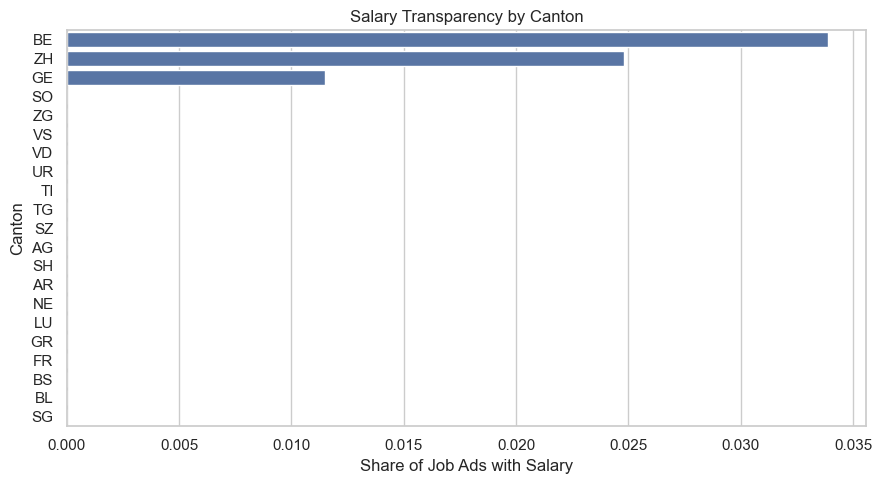

In [27]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=salary_region.values,
    y=salary_region.index
)

plt.title("Salary Transparency by Canton")
plt.xlabel("Share of Job Ads with Salary")
plt.ylabel("Canton")

plt.tight_layout()
plt.show()

*Figure: Salary transparency by canton.*

The results suggest that salary transparency varies across Swiss cantons. Some regions show a slightly higher proportion of job postings that include salary information, while others show almost no salary disclosure.

However, the overall level of salary transparency remains very low across the dataset, so these differences should be interpreted with caution.

## Salary Transparency Patterns

The final research question focuses on patterns in salary transparency across different job roles. By comparing salary disclosure rates across roles, we can determine whether certain positions are more likely to include salary information in job advertisements.

In [28]:
salary_role = (
    df.groupby("role")["salary_available"]
    .mean()
    .sort_values(ascending=False)
)

salary_role = salary_role[salary_role > 0]
salary_role

role
data scientist    0.032787
data engineer     0.011161
Name: salary_available, dtype: float64

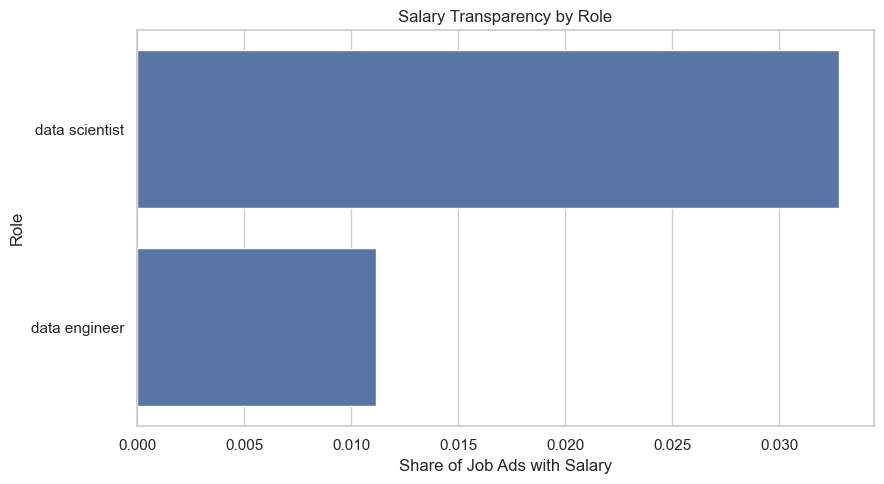

In [29]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=salary_role.values,
    y=salary_role.index
)

plt.title("Salary Transparency by Role")
plt.xlabel("Share of Job Ads with Salary")
plt.ylabel("Role")

plt.tight_layout()
plt.show()

*Figure: Salary transparency by role.*

The results show that salary transparency varies slightly across job roles. 
Only Data Scientist and Data Engineer positions include salary information in a small share of job advertisements. 
For other roles, salary information is not disclosed in the dataset. 
Overall, salary transparency remains extremely limited across the Swiss data job market.

## Summary of Findings

The analysis reveals several important patterns in the Swiss data job market. Data Engineer roles appear most frequently in the dataset, followed by Data Scientist and Data Analyst positions. Skill requirements vary across roles, with technically specialized positions requiring a broader set of competencies.

Job opportunities are concentrated in key cantons such as Zurich, Geneva, Vaud, and Bern, reflecting the presence of major economic and technological hubs. Regional comparisons also suggest that the average number of required skills differs across locations, although these differences should be interpreted with caution because the number of postings varies by canton.

Finally, salary transparency remains extremely limited in the dataset. Only about 1% of job advertisements include salary information, indicating that most employers do not disclose compensation details in job postings.

## Data Limitations

Several limitations of the dataset should be noted. First, some job postings do not contain precise location information, which results in a small number of entries with missing regional attributes. This may slightly affect regional comparisons.

Second, salary information is rarely included in job advertisements. Because only a very small proportion of postings provide salary details, analyses related to salary transparency should be interpreted with caution.

Third, seniority information is missing for many job postings because not all job titles explicitly indicate a level such as junior, senior, or lead.

Finally, the dataset consists of currently active job postings collected within a limited time window. Therefore, the findings reflect a snapshot of the Swiss data job market rather than long-term trends.